In [40]:
import pandas as pd

df_id = pd.read_csv('../data/train_identity.csv')#, nrows=100)

print(df_id.head())

   TransactionID  id_01     id_02  id_03  id_04  id_05  id_06  id_07  id_08  \
0        2987004    0.0   70787.0    NaN    NaN    NaN    NaN    NaN    NaN   
1        2987008   -5.0   98945.0    NaN    NaN    0.0   -5.0    NaN    NaN   
2        2987010   -5.0  191631.0    0.0    0.0    0.0    0.0    NaN    NaN   
3        2987011   -5.0  221832.0    NaN    NaN    0.0   -6.0    NaN    NaN   
4        2987016    0.0    7460.0    0.0    0.0    1.0    0.0    NaN    NaN   

   id_09  ...                id_31  id_32      id_33           id_34  id_35  \
0    NaN  ...  samsung browser 6.2   32.0  2220x1080  match_status:2      T   
1    NaN  ...   mobile safari 11.0   32.0   1334x750  match_status:1      T   
2    0.0  ...          chrome 62.0    NaN        NaN             NaN      F   
3    NaN  ...          chrome 62.0    NaN        NaN             NaN      F   
4    0.0  ...          chrome 62.0   24.0   1280x800  match_status:2      T   

  id_36 id_37  id_38  DeviceType                  

In [41]:
df_trans = pd.read_csv('../data/train_transaction.csv')#, nrows=100)

print(df_trans.head())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   NaN   NaN  

### check for duplicate transactionIDs in either dataframe, since it would lead to problems.

In [42]:
print(df_id.duplicated('TransactionID').sum())
print(df_trans.duplicated('TransactionID').sum())

0
0


### combine transactions and identifiers into one dataframe

In [43]:
df = df_trans.merge(df_id, how='left', on='TransactionID', validate='one_to_one')

In [44]:
df.select_dtypes(include=('str','object')).nunique().sort_values()

M2                  2
M3                  2
M1                  2
id_12               2
M8                  2
M7                  2
M6                  2
M5                  2
M9                  2
id_36               2
id_37               2
id_38               2
id_29               2
id_28               2
id_27               2
id_16               2
DeviceType          2
id_35               2
M4                  3
id_23               3
id_15               3
card4               4
id_34               4
card6               4
ProductCD           5
P_emaildomain      59
R_emaildomain      60
id_30              75
id_31             130
id_33             260
DeviceInfo       1786
dtype: int64

### drop all non-numeric fields

In [7]:
'''string_cols = df.select_dtypes(include=['str', 'object', 'category']).columns
print(string_cols)

#df[string_cols] = df[string_cols].astype('category')

df.drop(columns=string_cols, inplace=True)


print(df.columns.tolist())'''

"string_cols = df.select_dtypes(include=['str', 'object', 'category']).columns\nprint(string_cols)\n\n#df[string_cols] = df[string_cols].astype('category')\n\ndf.drop(columns=string_cols, inplace=True)\n\n\nprint(df.columns.tolist())"

In [45]:
list(df.dtypes.items())

[('TransactionID', dtype('int64')),
 ('isFraud', dtype('int64')),
 ('TransactionDT', dtype('int64')),
 ('TransactionAmt', dtype('float64')),
 ('ProductCD', <StringDtype(storage='python', na_value=nan)>),
 ('card1', dtype('int64')),
 ('card2', dtype('float64')),
 ('card3', dtype('float64')),
 ('card4', <StringDtype(storage='python', na_value=nan)>),
 ('card5', dtype('float64')),
 ('card6', <StringDtype(storage='python', na_value=nan)>),
 ('addr1', dtype('float64')),
 ('addr2', dtype('float64')),
 ('dist1', dtype('float64')),
 ('dist2', dtype('float64')),
 ('P_emaildomain', <StringDtype(storage='python', na_value=nan)>),
 ('R_emaildomain', <StringDtype(storage='python', na_value=nan)>),
 ('C1', dtype('float64')),
 ('C2', dtype('float64')),
 ('C3', dtype('float64')),
 ('C4', dtype('float64')),
 ('C5', dtype('float64')),
 ('C6', dtype('float64')),
 ('C7', dtype('float64')),
 ('C8', dtype('float64')),
 ('C9', dtype('float64')),
 ('C10', dtype('float64')),
 ('C11', dtype('float64')),
 ('C12'

In [46]:
print(df.drop('isFraud',axis=1).shape)
print(df['isFraud'].shape)

(590540, 433)
(590540,)


### convert low cardinality fields to categories

In [58]:
low_card_cols = [c for c in df.select_dtypes(include=('str','object')).columns 
                 if df[c].nunique() <= 5 and c != 'isFraud']
print(low_card_cols)

high_card_cols = [c for c in df.select_dtypes(include=('str','object')).columns 
                 if df[c].nunique() > 5]
print(high_card_cols)

df[low_card_cols] = df[low_card_cols].astype('category')

['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']
['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33', 'DeviceInfo']


In [59]:
df['P_emaildomain'].value_counts(dropna=False).head(5)

P_emaildomain
gmail.com        228355
yahoo.com        100934
NaN               94456
hotmail.com       45250
anonymous.com     36998
Name: count, dtype: int64

### to prevent data leakage, time-split the training and test sets, with a buffer in between

In [69]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

train_idx = df['TransactionDT'] <= df['TransactionDT'].quantile(0.75)
test_idx = df['TransactionDT'] > df['TransactionDT'].quantile(0.80)

X_train, X_test, y_train, y_test = (
    df.drop('isFraud',axis=1)[train_idx],
    df.drop('isFraud',axis=1)[test_idx],
    df['isFraud'][train_idx],
    df['isFraud'][test_idx]
)
print(y_test[0:5])

#train = df[df['TransactionDT'] <= train_cutoff]
#test = df[df['TransactionDT'] >= test_start]

#print(f"Train fraud rate: {y_train.mean():.4f}")
#print(f"Test fraud rate:  {y_test.mean():.4f}")

'''X_train, X_test, y_train, y_test = train_test_split(
    df.drop('isFraud',axis=1),
    df['isFraud'],
    test_size=0.2,
    stratify=df['isFraud'],
    random_state=42
)'''

472432    1
472433    0
472434    0
472435    0
472436    0
Name: isFraud, dtype: int64


"X_train, X_test, y_train, y_test = train_test_split(\n    df.drop('isFraud',axis=1),\n    df['isFraud'],\n    test_size=0.2,\n    stratify=df['isFraud'],\n    random_state=42\n)"

### convert high cardinality string fields to their respective counts

In [70]:
X_train[high_card_cols[0]].value_counts(normalize=True)

P_emaildomain
gmail.com           0.457541
yahoo.com           0.202308
hotmail.com         0.093676
anonymous.com       0.075643
aol.com             0.056522
comcast.net         0.016365
icloud.com          0.012526
outlook.com         0.010114
msn.com             0.008392
att.net             0.007817
live.com            0.006253
sbcglobal.net       0.006037
verizon.net         0.005660
ymail.com           0.004826
bellsouth.net       0.003981
yahoo.com.mx        0.003259
me.com              0.003232
cox.net             0.002823
optonline.net       0.002128
charter.net         0.001767
live.com.mx         0.001559
rocketmail.com      0.001321
mail.com            0.001123
earthlink.net       0.001024
gmail               0.001016
outlook.es          0.000965
mac.com             0.000917
juno.com            0.000668
aim.com             0.000668
roadrunner.com      0.000639
hotmail.es          0.000591
hotmail.fr          0.000569
frontier.com        0.000556
windstream.net      0.000548


In [71]:
for col in high_card_cols:
    freq = X_train[col].value_counts(normalize=True)
    X_train[col + '_freq'] = X_train[col].map(freq)
    X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)

X_train = X_train.drop(columns=high_card_cols)
X_test = X_test.drop(columns=high_card_cols)

/tmp/ipykernel_55062/226209226.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[col + '_freq'] = X_train[col].map(freq)
/tmp/ipykernel_55062/226209226.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)


In [72]:
list(X_train.dtypes.items())

[('TransactionID', dtype('int64')),
 ('TransactionDT', dtype('int64')),
 ('TransactionAmt', dtype('float64')),
 ('ProductCD',
  CategoricalDtype(categories=['C', 'H', 'R', 'S', 'W'], ordered=False, categories_dtype=str)),
 ('card1', dtype('int64')),
 ('card2', dtype('float64')),
 ('card3', dtype('float64')),
 ('card4',
  CategoricalDtype(categories=['american express', 'discover', 'mastercard', 'visa'], ordered=False, categories_dtype=str)),
 ('card5', dtype('float64')),
 ('card6',
  CategoricalDtype(categories=['charge card', 'credit', 'debit', 'debit or credit'], ordered=False, categories_dtype=str)),
 ('addr1', dtype('float64')),
 ('addr2', dtype('float64')),
 ('dist1', dtype('float64')),
 ('dist2', dtype('float64')),
 ('C1', dtype('float64')),
 ('C2', dtype('float64')),
 ('C3', dtype('float64')),
 ('C4', dtype('float64')),
 ('C5', dtype('float64')),
 ('C6', dtype('float64')),
 ('C7', dtype('float64')),
 ('C8', dtype('float64')),
 ('C9', dtype('float64')),
 ('C10', dtype('float64'))

In [73]:
# compute imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

print(f"1/Train fraud rate: {1/y_train.mean():.4f}")
print(f"1/Test fraud rate:  {1/y_test.mean():.4f}")

27.458844695752745
1/Train fraud rate: 28.4588
1/Test fraud rate:  29.0620


### scale features

In [74]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()

ct = ColumnTransformer(
    [('num', StandardScaler(), numeric_cols)],
    remainder='passthrough'
)
ct.set_output(transform='pandas')


pipe = Pipeline([
    ('prep', ct),
    ('model', XGBClassifier(
        enable_categorical=True,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    ))
])


In [75]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [76]:
pipe.predict_proba(X_test)[:, 1]

array([0.35805798, 0.13574052, 0.8369476 , ..., 0.19248368, 0.5004977 ,
       0.2511465 ], shape=(118108,), dtype=float32)

In [ ]:
'''model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    enable_categorical=True
)'''

In [ ]:
# took 83 seconds
#model.fit(X_train, y_train)

In [77]:
# predictions
preds = pipe.predict(X_test)
probs = pipe.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, preds))

print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93    114044
           1       0.18      0.75      0.29      4064

    accuracy                           0.87    118108
   macro avg       0.58      0.81      0.61    118108
weighted avg       0.96      0.87      0.91    118108

ROC-AUC: 0.8938684642576135


              precision    recall  f1-score   support

           0       0.99      0.91      0.95    113975
           1       0.24      0.80      0.37      4133

    accuracy                           0.90    118108
   macro avg       0.61      0.85      0.66    118108
weighted avg       0.97      0.90      0.93    118108

ROC-AUC: 0.9302605349535278

In [78]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, probs)
print("PR-AUC:", average_precision_score(y_test, probs))

PR-AUC: 0.48118555036258215


In [80]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

for t in np.arange(0.1, 0.95, 0.05):
    preds_t = (probs >= t).astype(int)
    p = precision_score(y_test, preds_t)
    r = recall_score(y_test, preds_t)
    n_flagged = preds_t.sum()
    print(f"{t:.2f}  precision={p:.3f}  recall={r:.3f}  flagged={n_flagged}")

0.10  precision=0.043  recall=0.988  flagged=93770
0.15  precision=0.052  recall=0.969  flagged=75101
0.20  precision=0.065  recall=0.939  flagged=58969
0.25  precision=0.081  recall=0.913  flagged=45694
0.30  precision=0.099  recall=0.883  flagged=36366
0.35  precision=0.116  recall=0.846  flagged=29734
0.40  precision=0.135  recall=0.816  flagged=24652
0.45  precision=0.155  recall=0.789  flagged=20615
0.50  precision=0.178  recall=0.753  flagged=17182
0.55  precision=0.202  recall=0.711  flagged=14291
0.60  precision=0.231  recall=0.665  flagged=11703
0.65  precision=0.266  recall=0.618  flagged=9440
0.70  precision=0.311  recall=0.566  flagged=7411
0.75  precision=0.373  recall=0.517  flagged=5625
0.80  precision=0.452  recall=0.456  flagged=4100
0.85  precision=0.558  recall=0.405  flagged=2948
0.90  precision=0.706  recall=0.349  flagged=2011


In [87]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs)
#print(precision.tolist())
idx = np.argmax(precision >= 0.50)   # first threshold reaching 50% precision
print(f"threshold={thresholds[idx]:.3f}, recall={recall[idx]:.3f}")

idx = np.argmax(recall <= 0.50)   # first threshold reaching 50% precision
print(f"threshold={thresholds[idx]:.3f}, precision={precision[idx]:.3f}")

threshold=0.824, recall=0.429
threshold=0.764, precision=0.393


In [ ]:
# convert transactiondt into better value
# extract lowcard features

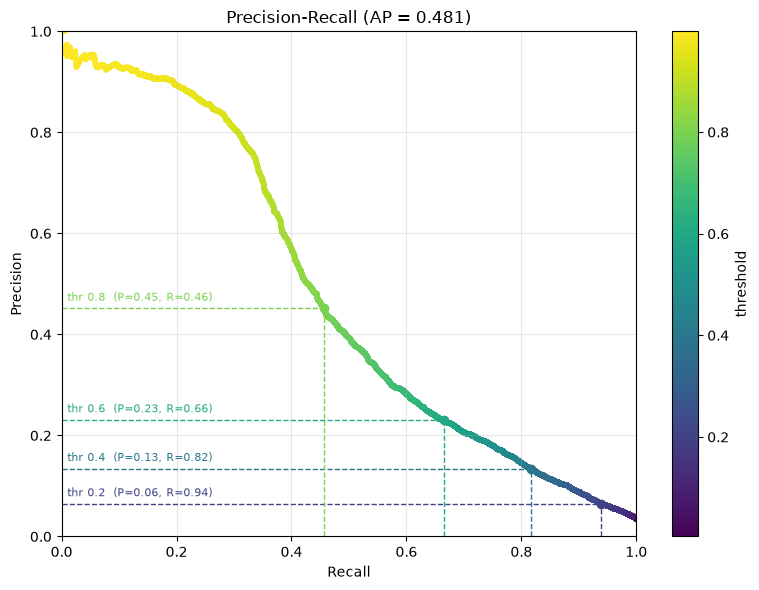

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, probs)
p, r = precision[:-1], recall[:-1]   # align with thresholds

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(r, p, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')


targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.searchsorted(thresholds, t)          # thresholds are ascending
    i = min(i, len(thresholds) - 1)
    r_t, p_t = r[i], p[i]
    
    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(p_t, 0, r_t, color=color, ls='--', lw=1)   # y-axis → curve
    ax.vlines(r_t, 0, p_t, color=color, ls='--', lw=1)   # x-axis → curve
    ax.plot(r_t, p_t, 'o', color=color, ms=6)
    ax.text(0.01, p_t + 0.015, f'thr {t}  (P={p_t:.2f}, R={r_t:.2f})',
            color=color, fontsize=8)


ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'Precision-Recall (AP = {average_precision_score(y_test, probs):.3f})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

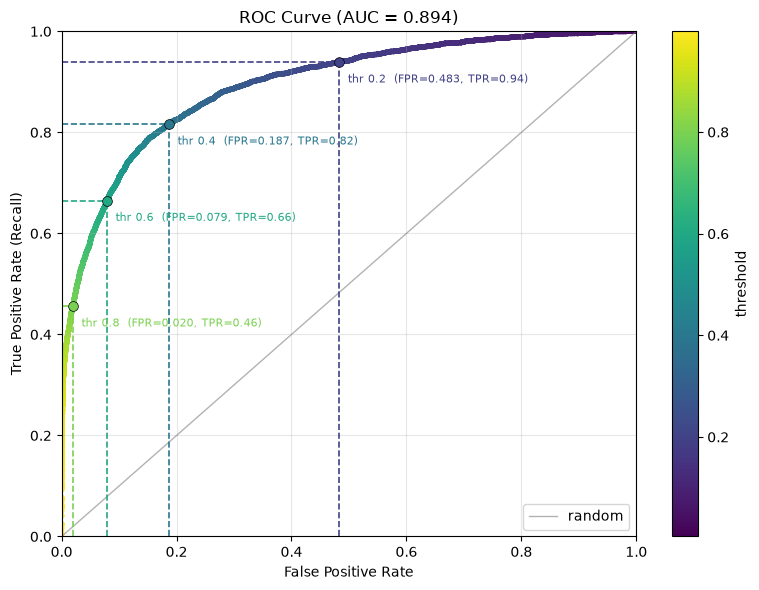

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, probs)

# roc_curve prepends an infinite threshold for the (0,0) point — drop it
fpr, tpr, thresholds = fpr[1:], tpr[1:], thresholds[1:]

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(fpr, tpr, c=thresholds, cmap='viridis', s=8)
plt.colorbar(sc, ax=ax, label='threshold')

ax.plot([0, 1], [0, 1], ls='-', lw=1, color='grey', alpha=0.6, label='random')

targets = [0.2, 0.4, 0.6, 0.8]

for t in targets:
    i = np.argmin(np.abs(thresholds - t))       # thresholds are descending here
    f_t, tp_t = fpr[i], tpr[i]

    color = sc.cmap(sc.norm(thresholds[i]))

    ax.hlines(tp_t, 0, f_t, color=color, ls='--', lw=1.2)
    ax.vlines(f_t, 0, tp_t, color=color, ls='--', lw=1.2)
    ax.plot(f_t, tp_t, 'o', color=color, ms=7, mec='black', mew=0.5)
    ax.text(f_t + 0.015, tp_t - 0.04, f'thr {t}  (FPR={f_t:.3f}, TPR={tp_t:.2f})',
            color=color, fontsize=8)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f'ROC Curve (AUC = {roc_auc_score(y_test, probs):.3f})')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()